In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from prophet import Prophet
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

# データ読み込み
sales_df = pd.read_csv("../data/raw/sales.csv")
sales_df["date"] = pd.to_datetime(sales_df["date"])

# 日別に集計
daily_df = sales_df.groupby("date").agg(
    total=("total", "sum"),
).reset_index()

# Prophet用にカラム名を変換（必須）
# Prophetはds（日付）とy（目的変数）という名前が必須
prophet_df = daily_df.rename(columns={"date": "ds", "total": "y"})

print(prophet_df.head())
print(f"\nレコード数：{len(prophet_df):,}件")

c:\Users\tozaw\projects\ai-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


          ds      y
0 2023-01-01  60400
1 2023-01-02  44100
2 2023-01-03  44750
3 2023-01-04  40350
4 2023-01-05  29650

レコード数：731件


In [2]:
# Prophetモデルの学習
model_prophet = Prophet(
    yearly_seasonality=True,   # 年間季節性を考慮
    weekly_seasonality=True,   # 週次季節性を考慮
    daily_seasonality=False,   # 日次季節性は不要
)

# 日本の祝日を追加
model_prophet.add_country_holidays(country_name="JP")

# 学習
model_prophet.fit(prophet_df)

print("学習完了！")

15:19:54 - cmdstanpy - INFO - Chain [1] start processing
15:19:56 - cmdstanpy - INFO - Chain [1] done processing


学習完了！


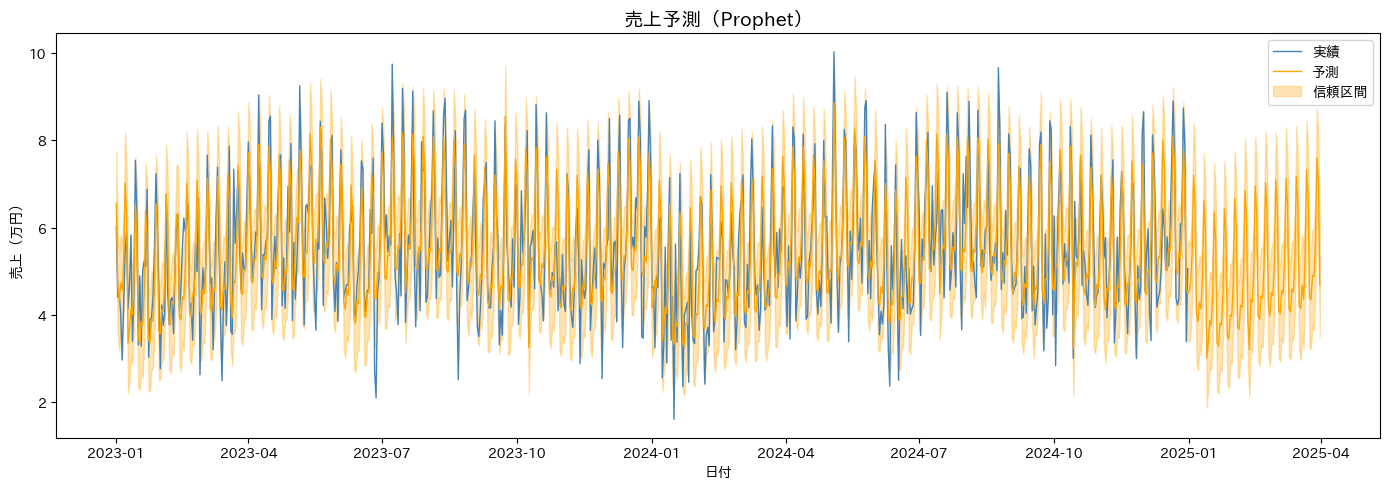

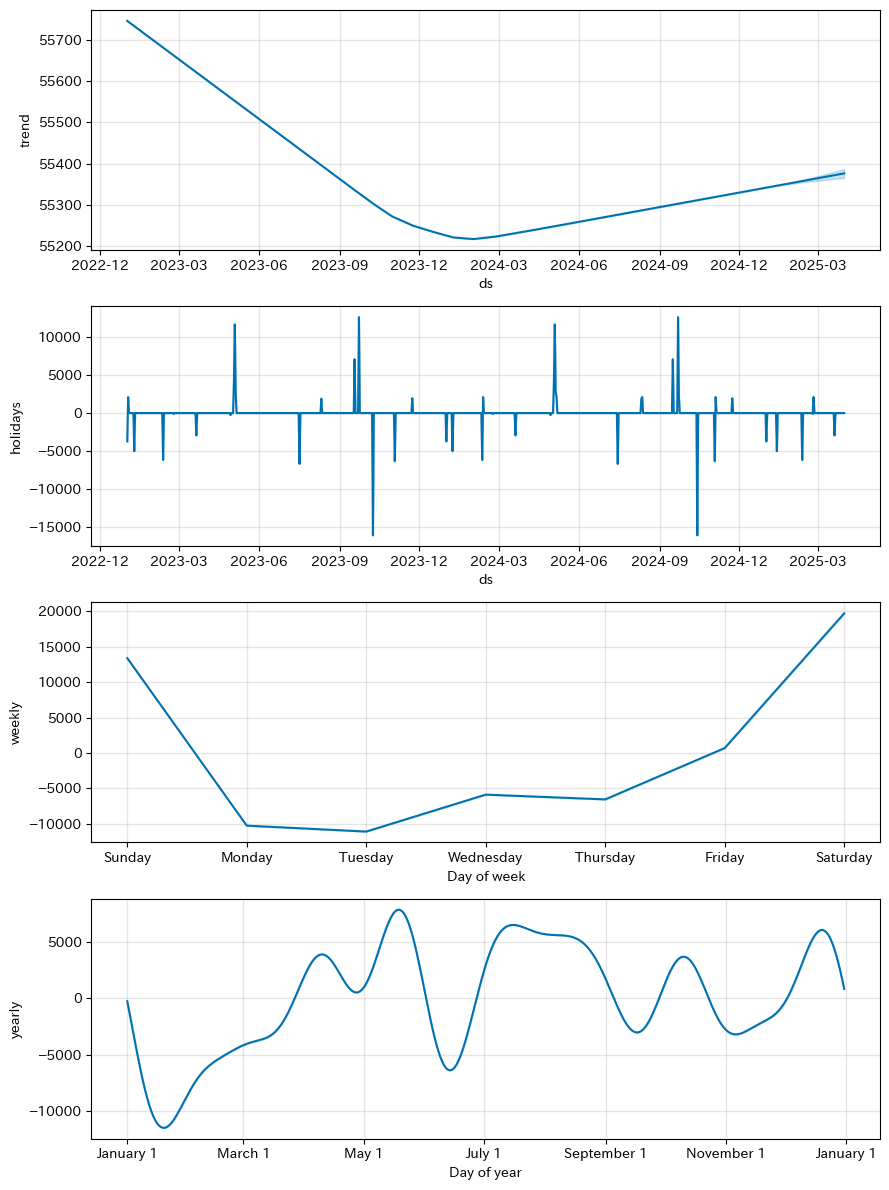

In [3]:
# 将来90日分の予測
future = model_prophet.make_future_dataframe(periods=90)
forecast = model_prophet.predict(future)

# ===== 予測グラフ =====
fig, ax = plt.subplots(figsize=(14, 5))

# 実績値
ax.plot(prophet_df["ds"], prophet_df["y"] / 10000,
        color="steelblue", label="実績", linewidth=1)

# 予測値
ax.plot(forecast["ds"], forecast["yhat"] / 10000,
        color="orange", label="予測", linewidth=1)

# 予測の信頼区間
ax.fill_between(
    forecast["ds"],
    forecast["yhat_lower"] / 10000,
    forecast["yhat_upper"] / 10000,
    alpha=0.3, color="orange", label="信頼区間"
)

ax.set_title("売上予測（Prophet）", fontsize=14)
ax.set_xlabel("日付")
ax.set_ylabel("売上（万円）")
ax.legend()
plt.tight_layout()
plt.show()

# ===== トレンド・季節性の分解 =====
fig2 = model_prophet.plot_components(forecast)
plt.tight_layout()
plt.show()

In [4]:
# Prophetモデルの保存
with open("../ml/models/prophet_model.pkl", "wb") as f:
    pickle.dump(model_prophet, f)

print("Prophetモデルの保存完了！")
print("保存先：../ml/models/prophet_model.pkl")

Prophetモデルの保存完了！
保存先：../ml/models/prophet_model.pkl
